# Import Libraries

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering


# Load the Dataset

In [205]:
data = pd.read_csv("IBM_HR_analyticisEmployee.csv")

In [206]:
df = data.copy()

In [207]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [208]:
df.shape

(1470, 35)

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [210]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Data Quality Assessment

In [211]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [212]:
df.duplicated().sum()

np.int64(0)

In [213]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

| Column                       | Description                                                                 |
| ---------------------------- | --------------------------------------------------------------------------- |
| **Age**                      | Age of the employee.                                                        |
| **Attrition**                | Whether the employee left the company (Yes/No).                             |
| **BusinessTravel**           | Frequency of business travel.                                               |
| **DailyRate**                | Employee's daily pay rate.                                                  |
| **Department**               | Department where the employee works.                                        |
| **DistanceFromHome**         | Distance between the employee's home and workplace.                         |
| **Education**                | Employee's education level (1–5).                                           |
| **EducationField**           | Field of study of the employee.                                             |
| **EmployeeCount**            | Total employee count (constant value = 1).                                  |
| **EmployeeNumber**           | Unique identifier assigned to each employee.                                |
| **EnvironmentSatisfaction**  | Employee's satisfaction with the work environment (1–4).                    |
| **Gender**                   | Employee's gender.                                                          |
| **HourlyRate**               | Employee's hourly pay rate.                                                 |
| **JobInvolvement**           | Level of involvement in the job (1–4).                                      |
| **JobLevel**                 | Employee's job level within the company.                                    |
| **JobRole**                  | Employee's job position or role.                                            |
| **JobSatisfaction**          | Employee's job satisfaction level (1–4).                                    |
| **MaritalStatus**            | Employee's marital status.                                                  |
| **MonthlyIncome**            | Employee's monthly salary.                                                  |
| **MonthlyRate**              | Monthly rate assigned to the employee.                                      |
| **NumCompaniesWorked**       | Number of companies the employee has worked for previously.                 |
| **Over18**                   | Indicates whether the employee is over 18 years old (constant value = "Y"). |
| **OverTime**                 | Whether the employee works overtime (Yes/No).                               |
| **PercentSalaryHike**        | Percentage increase in salary from the previous year.                       |
| **PerformanceRating**        | Employee's performance rating.                                              |
| **RelationshipSatisfaction** | Satisfaction with workplace relationships (1–4).                            |
| **StandardHours**            | Standard working hours (constant value = 80).                               |
| **StockOptionLevel**         | Employee's stock option level.                                              |
| **TotalWorkingYears**        | Total years of professional work experience.                                |
| **TrainingTimesLastYear**    | Number of training sessions attended in the previous year.                  |
| **WorkLifeBalance**          | Employee's work-life balance rating (1–4).                                  |
| **YearsAtCompany**           | Number of years the employee has worked at the company.                     |
| **YearsInCurrentRole**       | Number of years in the current job role.                                    |
| **YearsSinceLastPromotion**  | Years since the employee's last promotion.                                  |
| **YearsWithCurrManager**     | Number of years working with the current manager.                           |


# Data Cleaning

In [214]:
df["EmployeeCount"].value_counts()

EmployeeCount
1    1470
Name: count, dtype: int64

In [215]:
df["Over18"].value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [216]:
df["StandardHours"].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

In [217]:
df["EmployeeNumber"].nunique()

1470

In [218]:
df["EmployeeNumber"].head()

0    1
1    2
2    4
3    5
4    7
Name: EmployeeNumber, dtype: int64

In [219]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [220]:
df = df.drop(columns=[
    "Attrition",
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

Five columns were removed during data cleaning. Three columns (EmployeeCount, Over18, and StandardHours) contained constant values for all records. EmployeeNumber was removed because it is only a unique identifier, and Attrition was removed because clustering is an unsupervised learning method and does not use a target variable.

In [221]:
df.shape

(1470, 30)

# EDA

In [222]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [223]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


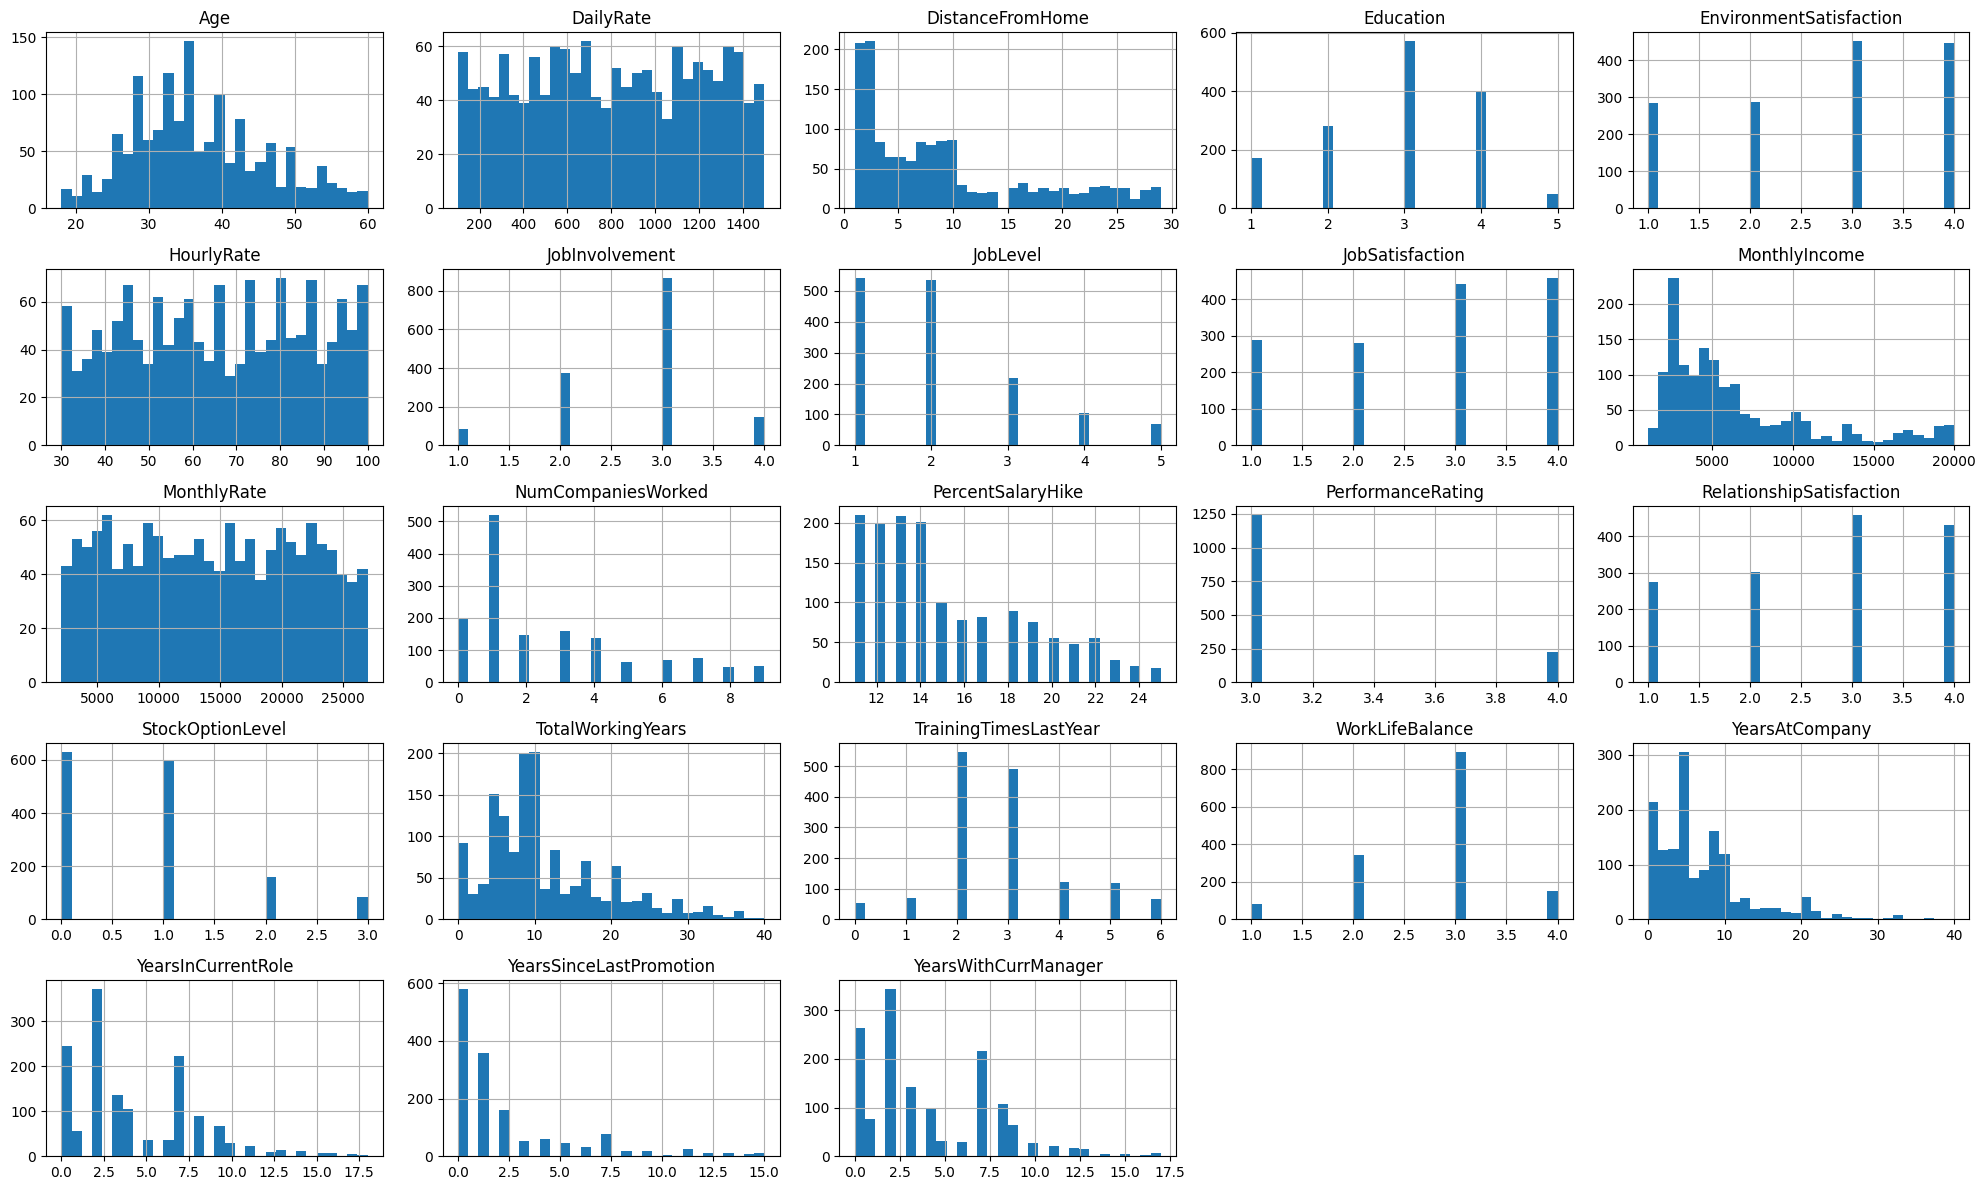

In [224]:
df.select_dtypes(include=["int64", "float64"]).hist(
    figsize=(20, 12),
    bins=30
)

plt.tight_layout()
plt.show()

The histograms indicate that the numerical features have different distribution patterns. Age is approximately normally distributed, while MonthlyIncome, TotalWorkingYears, and YearsAtCompany show positively skewed distributions, with most observations concentrated at lower values and fewer observations at higher values. In addition, variables such as Education, JobLevel, and WorkLifeBalance have discrete distributions because they represent ordinal categories encoded as numerical values rather than continuous measurements.

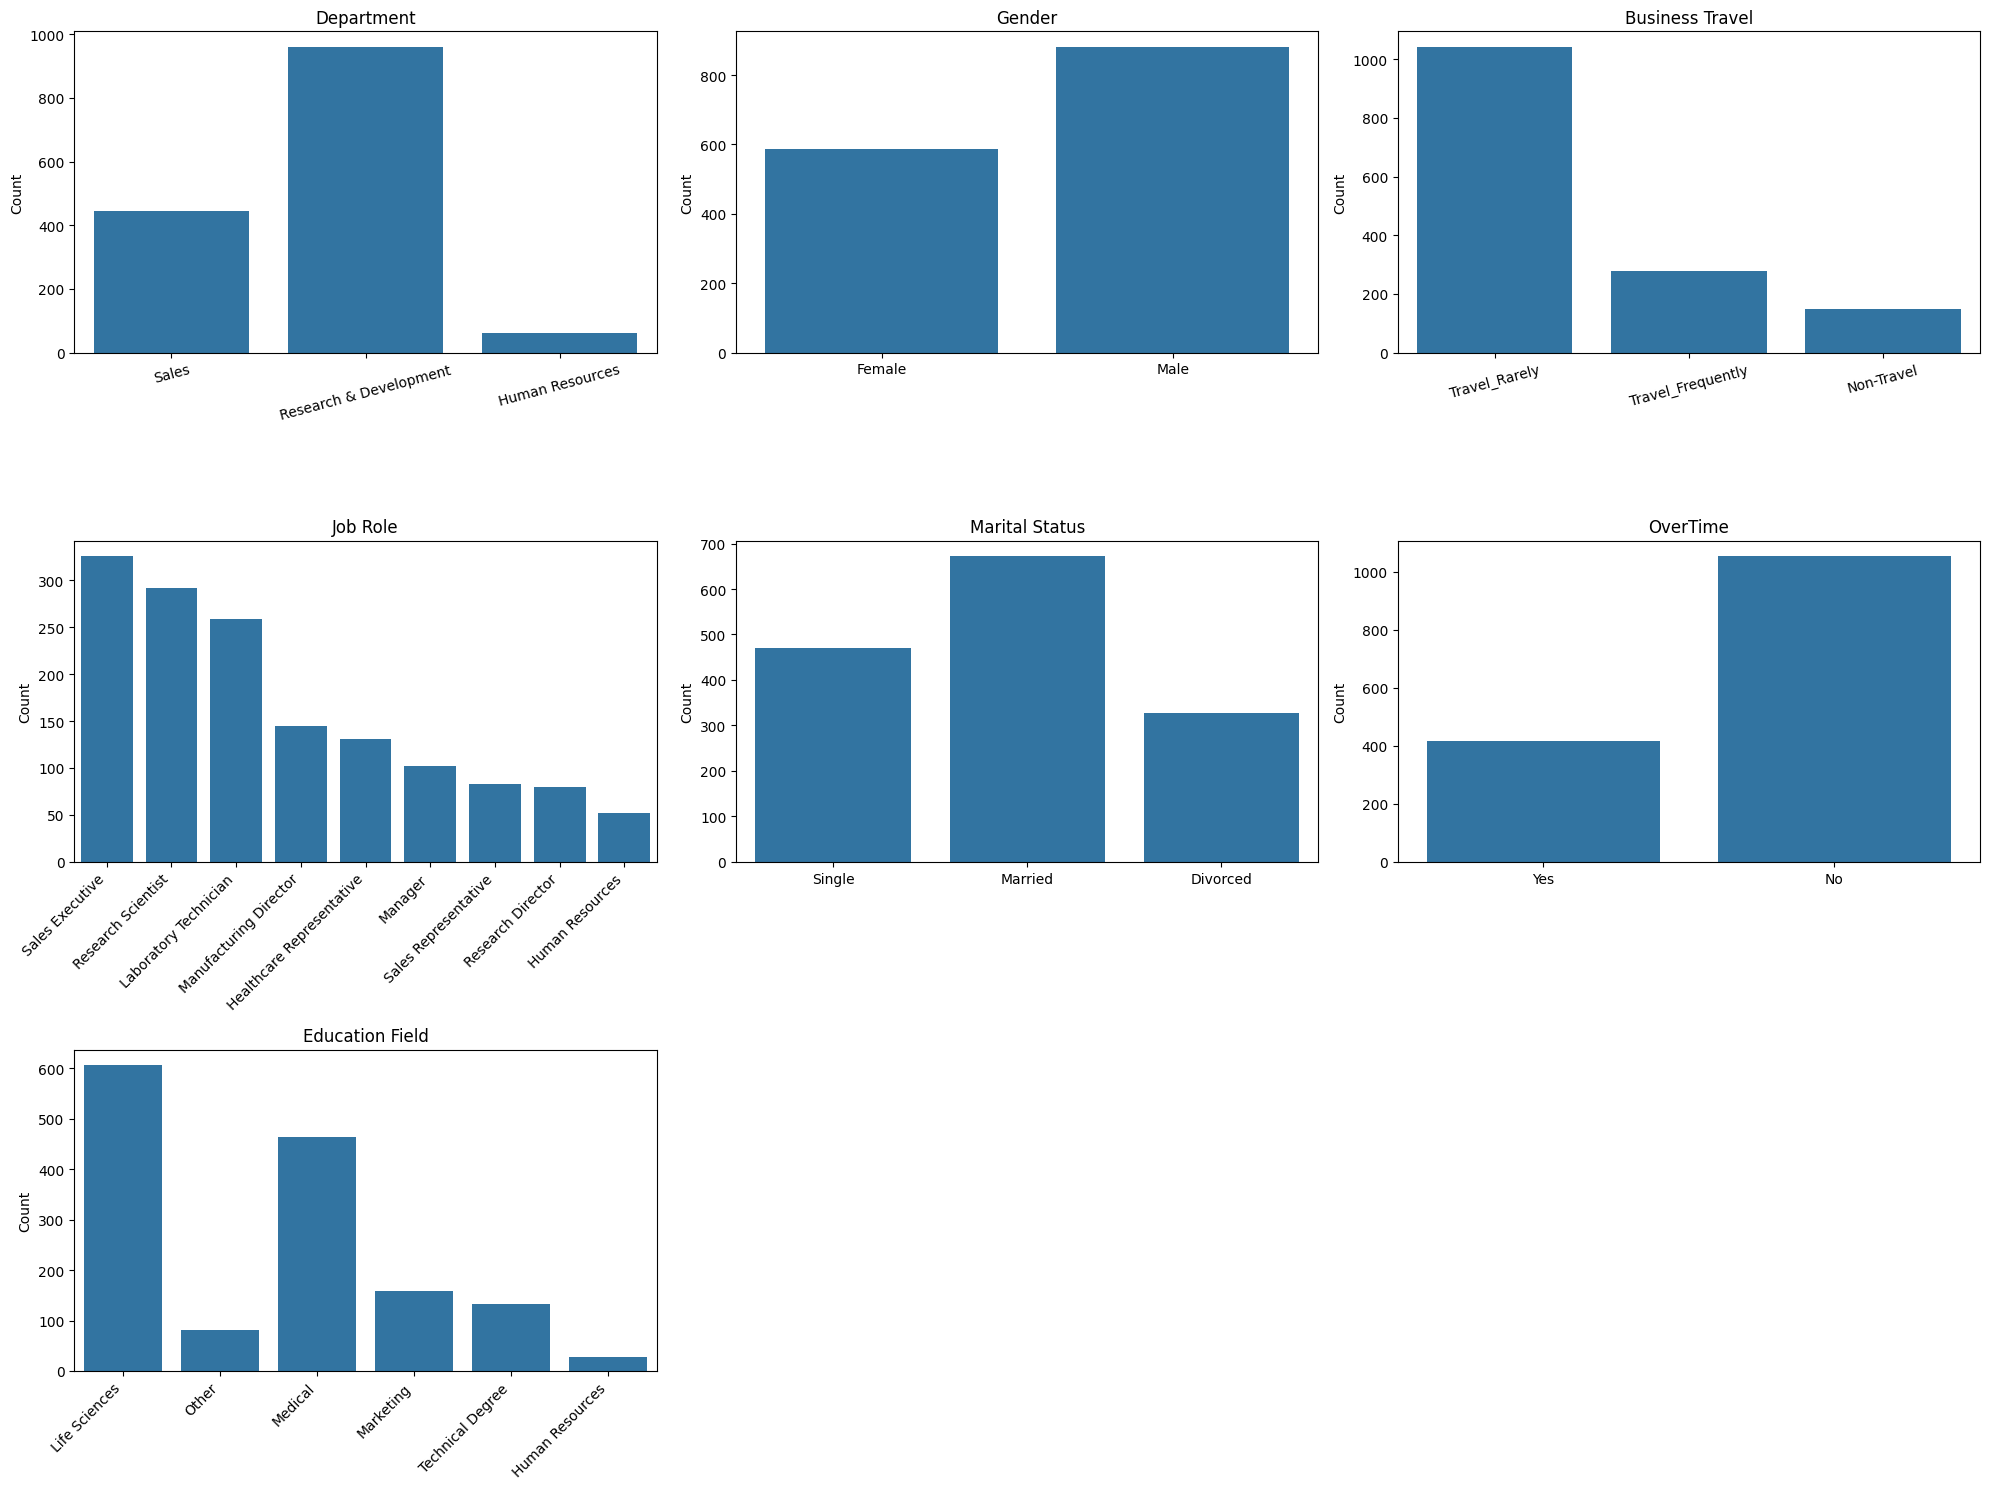

In [225]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Department
sns.countplot(data=df, x="Department", ax=axes[0, 0])
axes[0, 0].set_title("Department")
axes[0, 0].tick_params(axis='x', rotation=15)

# Gender
sns.countplot(data=df, x="Gender", ax=axes[0, 1])
axes[0, 1].set_title("Gender")

# Business Travel
sns.countplot(data=df, x="BusinessTravel", ax=axes[0, 2])
axes[0, 2].set_title("Business Travel")
axes[0, 2].tick_params(axis='x', rotation=15)

# Job Role
sns.countplot(data=df, x="JobRole", ax=axes[1, 0])
axes[1, 0].set_title("Job Role")
axes[1, 0].tick_params(axis='x', rotation=45)
for label in axes[1, 0].get_xticklabels():
    label.set_horizontalalignment('right')

# Marital Status
sns.countplot(data=df, x="MaritalStatus", ax=axes[1, 1])
axes[1, 1].set_title("Marital Status")

# OverTime
sns.countplot(data=df, x="OverTime", ax=axes[1, 2])
axes[1, 2].set_title("OverTime")

# Education Field
sns.countplot(data=df, x="EducationField", ax=axes[2, 0])
axes[2, 0].set_title("Education Field")
axes[2, 0].tick_params(axis='x', rotation=45)
for label in axes[2, 0].get_xticklabels():
    label.set_horizontalalignment('right')

# Hide empty subplots
axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

# Remove repeated axis labels
for ax in axes.flat:
    if ax.get_visible():
        ax.set_xlabel("")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Count plots were used to visualize the distribution of the categorical variables. The results show that most employees belong to the Research & Development department, while Human Resources has the fewest employees. Most employees travel rarely for business and do not work overtime. In addition, Sales Executive is the most common job role, and Life Sciences is the most common education field. These visualizations provide a better understanding of the distribution of categorical features before applying clustering techniques.

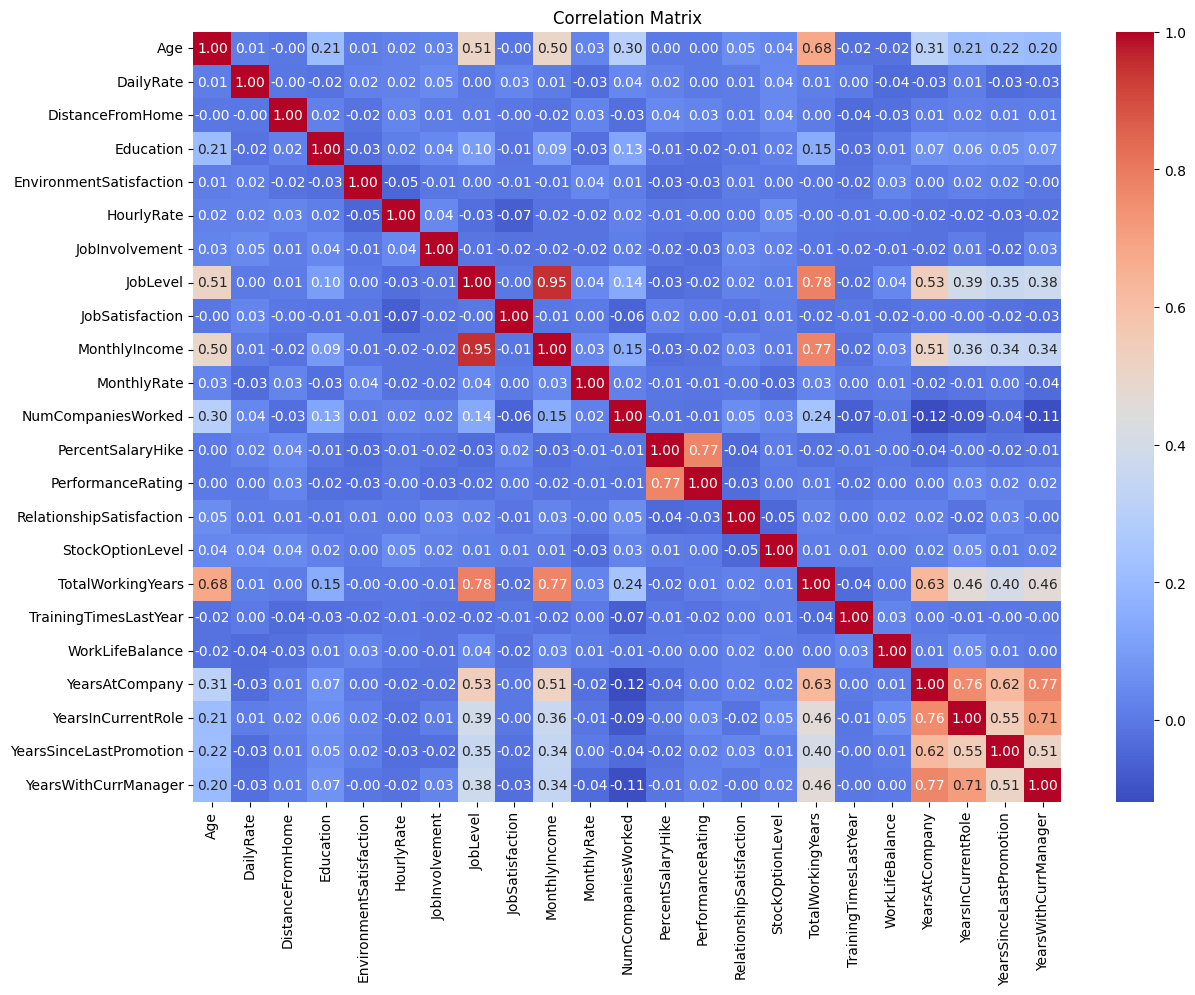

In [226]:
plt.figure(figsize=(14,10))

correlation = df[numerical_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that most numerical features have weak to moderate correlations. The strongest positive correlation is between JobLevel and MonthlyIncome (0.95), indicating that employees with higher job levels generally receive higher salaries. TotalWorkingYears is also strongly correlated with JobLevel (0.78) and MonthlyIncome (0.77). In addition, YearsAtCompany has strong positive relationships with both YearsWithCurrManager (0.77) and YearsInCurrentRole (0.76). Overall, while a few variables are highly correlated, most features provide distinct information, which is useful for clustering analysis.

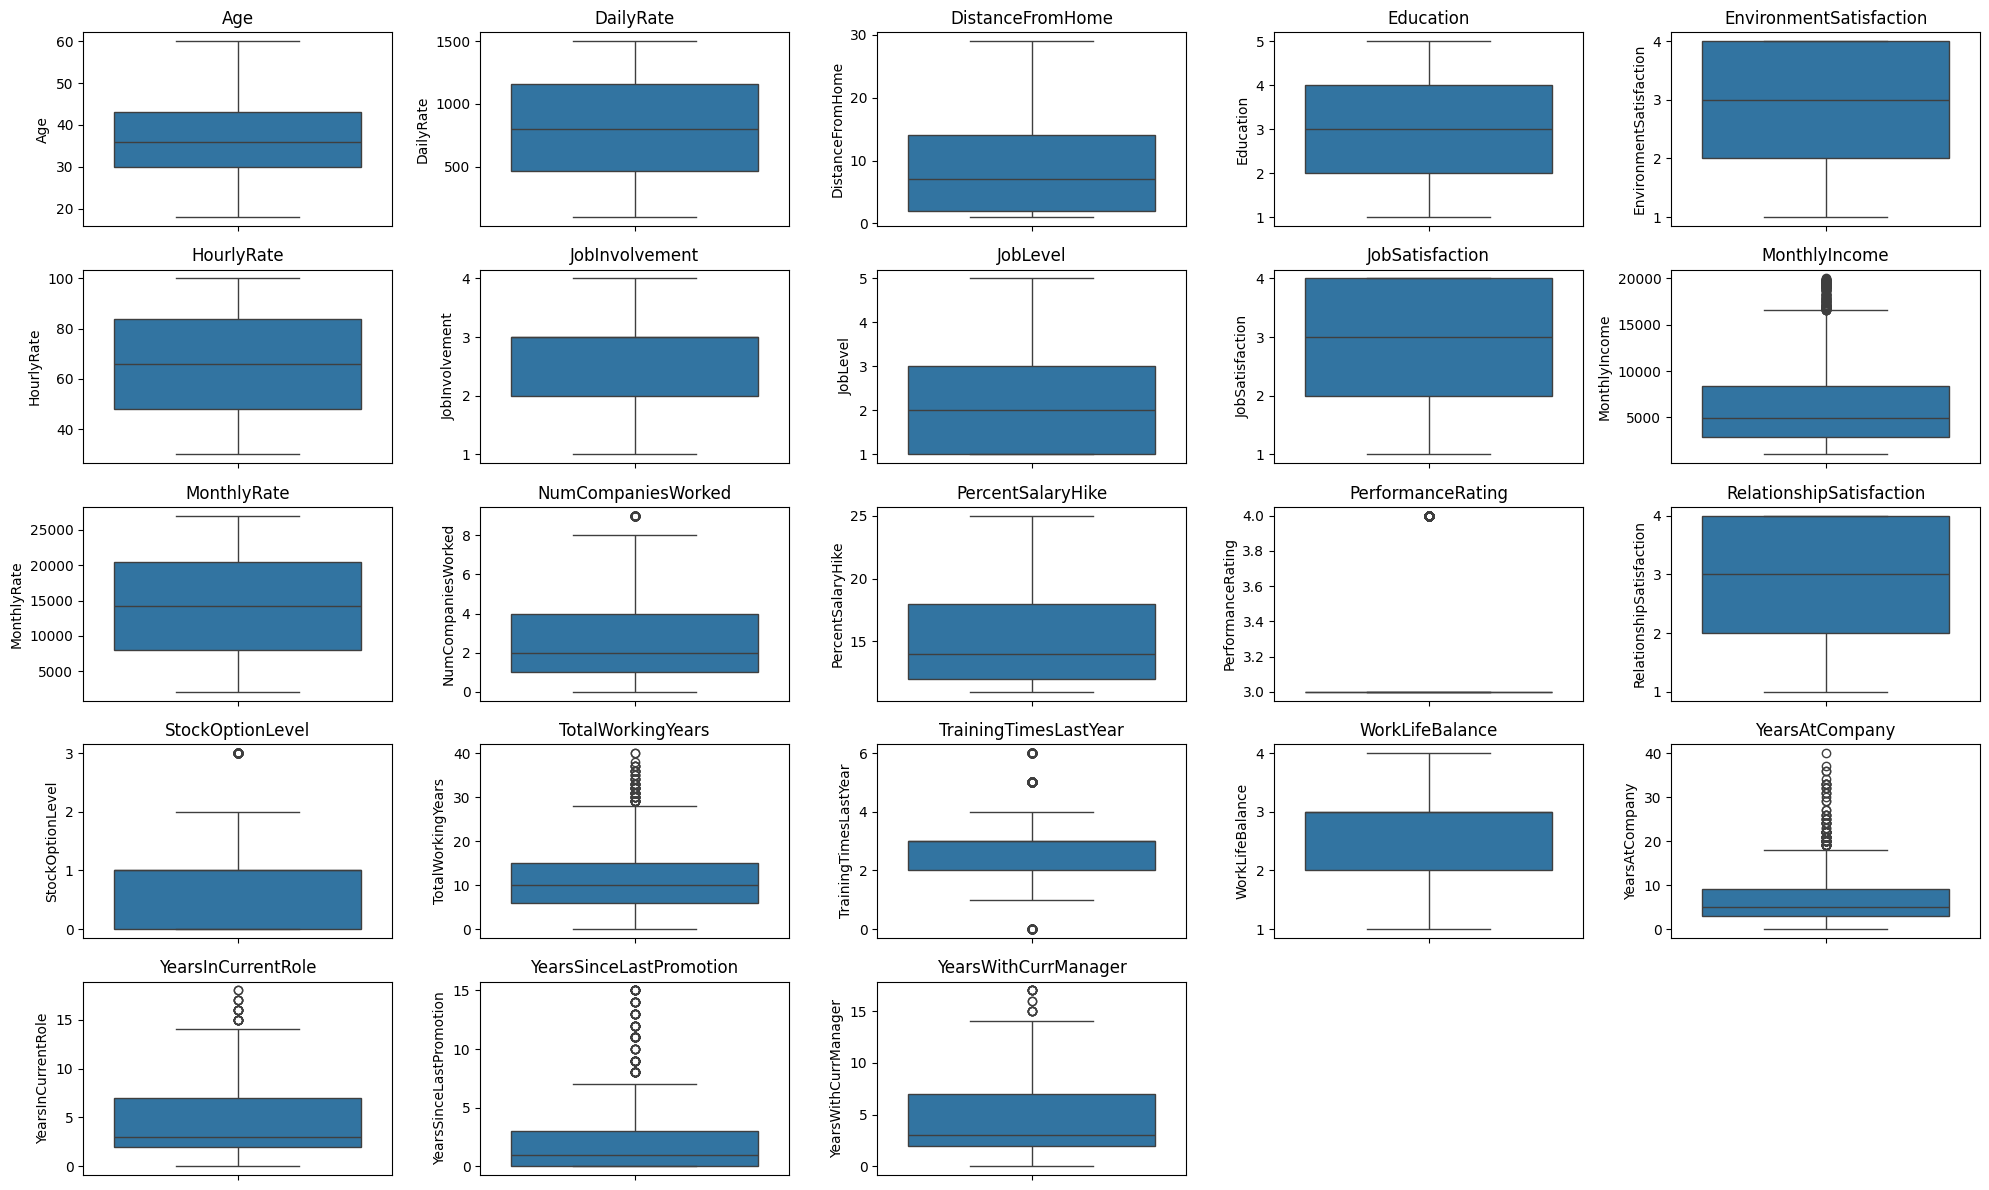

In [227]:
plt.figure(figsize=(20, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

The boxplots indicate that several numerical features contain outliers, particularly TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager. These values are likely to represent employees with long work experience rather than data entry errors. Therefore, the outliers were retained because they provide meaningful information for clustering analysis.

# Data Preprocessing

In [228]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [229]:
df_encoded.shape

(1470, 44)

In [230]:

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_encoded)

df_scaled

array([[ 0.4463504 ,  0.74252653, -1.01090934, ..., -0.91892141,
         1.45864991,  1.59174553],
       [ 1.32236521, -1.2977746 , -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [ 0.008343  ,  1.41436324, -0.88751511, ..., -0.91892141,
         1.45864991,  1.59174553],
       ...,
       [-1.08667552, -1.60518328, -0.64072665, ...,  1.08823234,
        -0.68556546,  1.59174553],
       [ 1.32236521,  0.54667746, -0.88751511, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [-0.32016256, -0.43256792, -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112]])

In [231]:
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

df_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-1.224745,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,0.816497,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,0.816497,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-1.224745,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,0.816497,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


In [232]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-0.034512,2.271801
1,0.097444,-1.569353
2,-2.871946,-0.993176
3,-1.222608,-1.126880
4,-2.075628,-1.211932


In [233]:
pca.explained_variance_ratio_
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.12130945 0.07848152]
0.19979096720315975


In [234]:
pca_3d = PCA(n_components=3)

pca_data_3d = pca_3d.fit_transform(df_scaled)

print(pca_3d.explained_variance_ratio_)
print(sum(pca_3d.explained_variance_ratio_))

[0.12130945 0.07848152 0.04705972]
0.24685069139870738


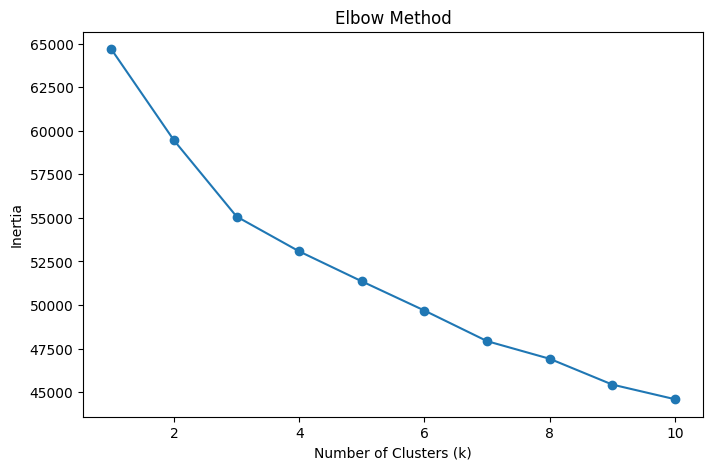

In [235]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

The Elbow Method indicates that the optimal number of clusters is 3

# K-Means

In [236]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(df_scaled)

pca_df["Cluster"] = clusters

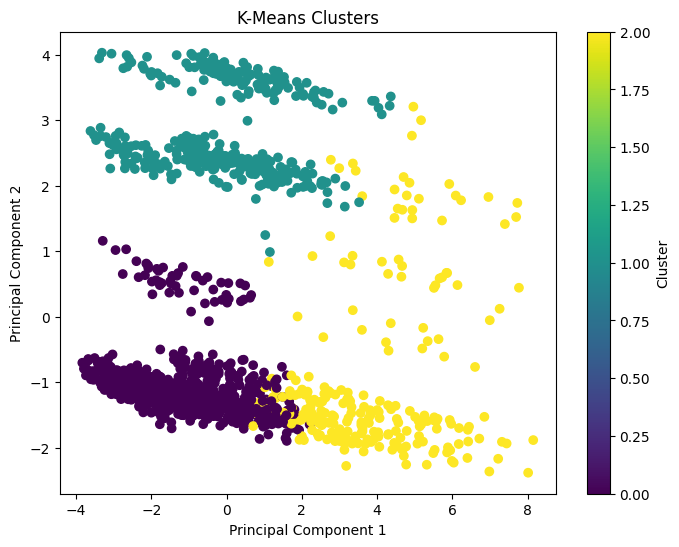

In [237]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap="viridis"
)

plt.title("K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

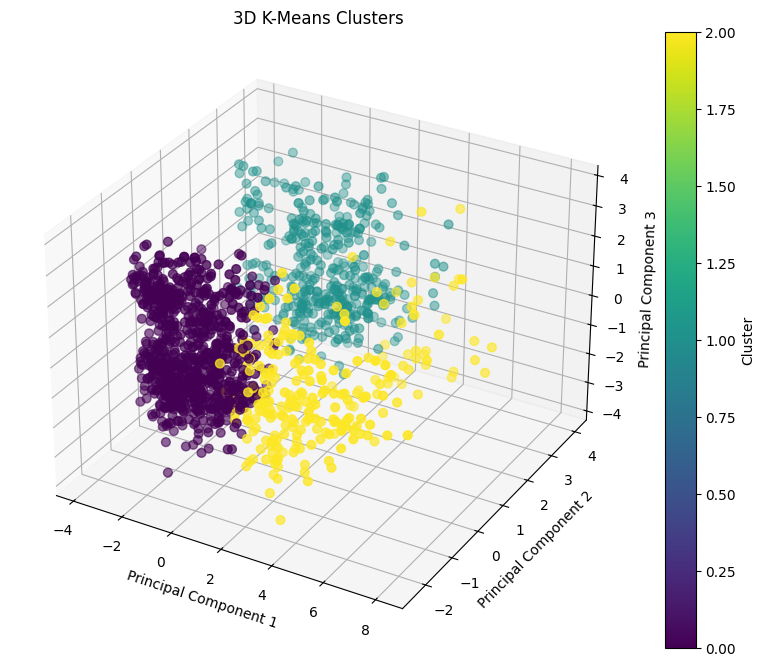

In [238]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pca_data_3d[:, 0],
    pca_data_3d[:, 1],
    pca_data_3d[:, 2],
    c=clusters,
    cmap="viridis",
    s=40
)

ax.set_title("3D K-Means Clusters")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

fig.colorbar(scatter, label="Cluster")

plt.show()

In [239]:
score = silhouette_score(df_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.09670362405428101


The K-Means model achieved a Silhouette Score of 0.097, indicating weak cluster separation. This suggests that the employee data contains overlapping characteristics, making it difficult to form highly distinct clusters. Such results are common in real-world HR datasets where employees often share similar attributes.

In [241]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.1162
k = 3, Silhouette Score = 0.0967
k = 4, Silhouette Score = 0.1046
k = 5, Silhouette Score = 0.0942
k = 6, Silhouette Score = 0.1061
k = 7, Silhouette Score = 0.1006
k = 8, Silhouette Score = 0.1009
k = 9, Silhouette Score = 0.1007
k = 10, Silhouette Score = 0.0883


# Hierarchical

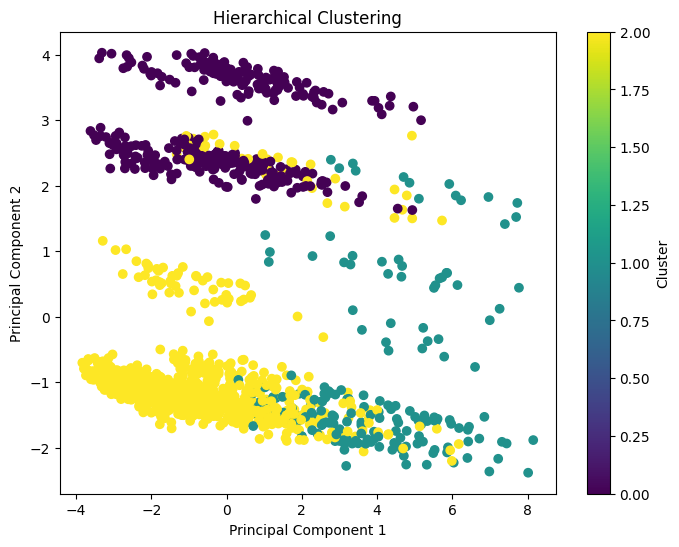

In [246]:

hc = AgglomerativeClustering(n_clusters=3)

clusters_hc = hc.fit_predict(df_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters_hc,
    cmap="viridis"
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

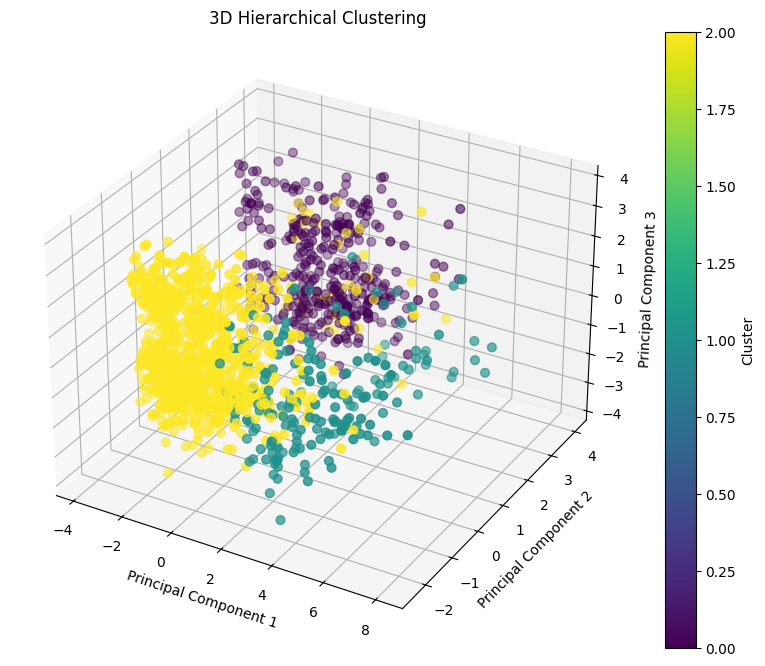

In [248]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_data_3d[:, 0],
    pca_data_3d[:, 1],
    pca_data_3d[:, 2],
    c=clusters_hc,
    cmap='viridis',
    s=40
)

ax.set_title("3D Hierarchical Clustering")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

fig.colorbar(scatter, label="Cluster")

plt.show()

In [249]:
hc_score = silhouette_score(df_scaled, clusters_hc)

print("Hierarchical Silhouette Score:", hc_score)

Hierarchical Silhouette Score: 0.08738520971147583


# DBSCAN

In [274]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=6.5, min_samples=5)

clusters_db = db.fit_predict(df_scaled)

In [275]:
print("Unique Labels:", set(clusters_db))

Unique Labels: {np.int64(0), np.int64(1), np.int64(-1)}


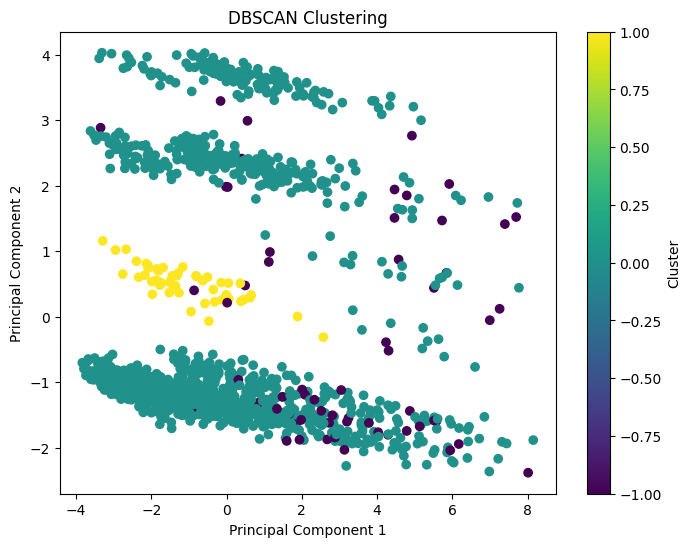

In [276]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters_db,
    cmap="viridis"
)

plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

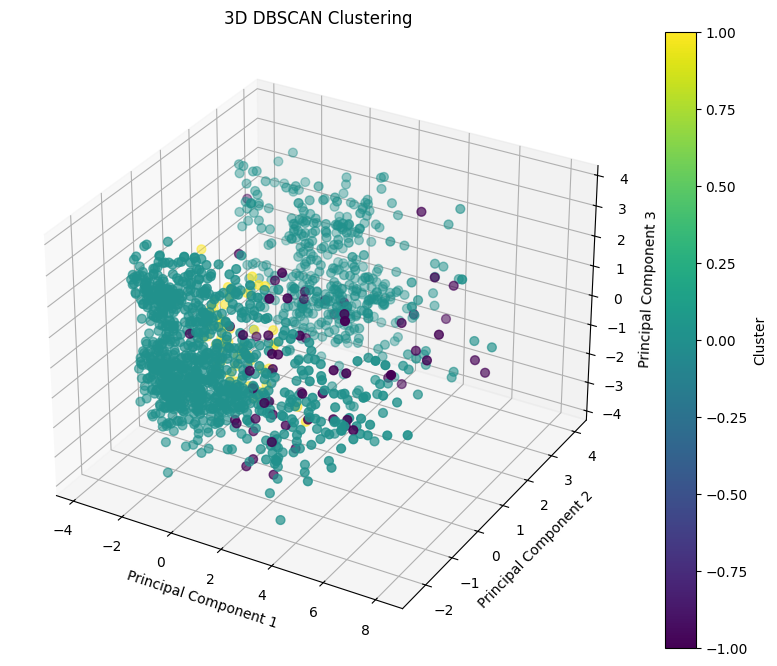

In [277]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pca_data_3d[:,0],
    pca_data_3d[:,1],
    pca_data_3d[:,2],
    c=clusters_db,
    cmap="viridis",
    s=40
)

ax.set_title("3D DBSCAN Clustering")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

fig.colorbar(scatter, label="Cluster")

plt.show()

In [278]:
mask = clusters_db != -1

db_score = silhouette_score(
    df_scaled[mask],
    clusters_db[mask]
)

print("DBSCAN Silhouette Score:", db_score)

DBSCAN Silhouette Score: 0.10951221062855473
